# CNN-Transformer — Training + Full Evaluation

Hybrid CNN-Transformer for drone audio detection.
Reuses the cached NPZ from the LWCNN notebook (same OUT_PATH).
Adds:
- Computational cost comparison vs LWCNN
- Temperature scaling (before/after)
- Confusion matrices at t=0.5 and t=0.05
- Joint threshold sweep
- Thesis-quality figures saved to Drive

In [1]:
!pip -q install datasets librosa numpy scikit-learn tensorflow pandas scipy matplotlib

import os, glob, zipfile, requests, time
import numpy as np
import pandas as pd
import librosa
import scipy.optimize
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras import layers, Model, mixed_precision
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from datasets import load_dataset

In [2]:
mixed_precision.set_global_policy('mixed_float16')
tf.config.optimizer.set_jit(True)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print('TF:', tf.__version__, '| Policy:', mixed_precision.global_policy())

TF: 2.20.0 | Policy: <DTypePolicy "mixed_float16">


In [3]:
from google.colab import drive
drive.mount('/content/drive')

SEED = 42
rng  = np.random.default_rng(SEED)
tf.random.set_seed(SEED)

WIN_S             = 0.5
HOP_S             = 0.25
MAX_WINDOWS_PER_CLIP = 10
SR_TARGET         = 16000
N_MELS            = 64
N_FFT             = 512
HOP_LENGTH        = 128
FMAX              = 8000
TOP_DB            = 80
TRAIN_FRAC        = 0.8
VAL_FRAC          = 0.1
TEST_FRAC         = 0.1

OUT_DIR    = '/content/drive/MyDrive/drone_audio_processed'
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH   = os.path.join(OUT_DIR, f'waveform_{WIN_S:.2f}s_hop{HOP_S:.2f}s_recordsplit.npz')
MODEL_PATH = os.path.join(OUT_DIR, 'model_cnntransformer_drone_binary.keras')
LWCNN_PATH = os.path.join(OUT_DIR, 'model_lwcnn_drone_binary.keras')  # for comparison
FIG_DIR    = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

AUG_PROB      = 0.7
SNR_MIN       = -5.0
SNR_MAX       = 20.0
MAX_MEL_SHIFT = 3
MAX_EQ_TILT   = 0.10
FREQ_MASK_MAX = 8
TIME_MASK_MAX = 8
TIME_STRETCH_PROB = 0.3
TIME_STRETCH_MIN  = 0.80
TIME_STRETCH_MAX  = 1.25

# CNN-Transformer hyperparameters
D_MODEL               = 128
NUM_HEADS             = 4
FFN_DIM               = 256
NUM_TRANSFORMER_LAYERS = 2
DROPOUT_RATE          = 0.30

BATCH    = 64
EPOCHS   = 30
AUTOTUNE = tf.data.AUTOTUNE

DEMAND_DIR         = '/content/DEMAND'
DEMAND_ZENODO_BASE = 'https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS    = ['DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
                       'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
                       'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO']
MAX_NOISE_CLIPS = None

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
CMAP = LinearSegmentedColormap.from_list('thesis_blue', ['#FFFFFF','#2E74B5'], N=256)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10})
print('Config loaded.')

Mounted at /content/drive
Config loaded.


In [4]:
# Helpers (identical to LWCNN notebook)
def log_mel_db(y, sr):
    y   = np.asarray(y, dtype=np.float32)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
                                          hop_length=HOP_LENGTH, fmax=FMAX, power=2.0)
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)

def windows_all(y, sr, win_s, hop_s, rng_local):
    y   = np.asarray(y, dtype=np.float32)
    win = int(round(win_s*sr)); hop = int(round(hop_s*sr))
    if len(y) <= win:
        out = np.zeros(win, dtype=np.float32)
        s   = rng_local.integers(0, win-len(y)+1)
        out[s:s+len(y)] = y; return [out]
    return [y[s:s+win] for s in range(0, len(y)-win+1, hop)]

def sample_windows(windows, k, rng_local):
    if k is None or len(windows) <= k: return windows
    return [windows[i] for i in rng_local.choice(len(windows), size=k, replace=False)]

def stratified_recording_split(indices, labels, train_frac, val_frac, test_frac, rng_local):
    idx0 = indices[labels[indices]==0]; idx1 = indices[labels[indices]==1]
    rng_local.shuffle(idx0); rng_local.shuffle(idx1)
    def split(arr):
        n=len(arr); a=int(round(train_frac*n)); b=int(round(val_frac*n))
        return arr[:a], arr[a:a+b], arr[a+b:]
    tr0,va0,te0 = split(idx0); tr1,va1,te1 = split(idx1)
    train=np.concatenate([tr0,tr1]); rng_local.shuffle(train)
    val=np.concatenate([va0,va1]);   rng_local.shuffle(val)
    test=np.concatenate([te0,te1]);  rng_local.shuffle(test)
    return train, val, test

def build_wave_windows(ds, rec_indices, rng_local):
    subset = ds.select(rec_indices.tolist())
    X_wav, y_out = [], []
    for i, s in enumerate(subset):
        if i % 5000 == 0: print(f'  {i}/{len(rec_indices)}')
        label = int(s['label'])
        y = np.asarray(s['audio']['array'], dtype=np.float32)
        sr = int(s['audio']['sampling_rate'])
        if sr != SR_TARGET: y = librosa.resample(y, orig_sr=sr, target_sr=SR_TARGET)
        wins = sample_windows(windows_all(y, SR_TARGET, WIN_S, HOP_S, rng_local), MAX_WINDOWS_PER_CLIP, rng_local)
        for w in wins: X_wav.append(w); y_out.append(label)
    return np.stack(X_wav).astype(np.float32), np.array(y_out, dtype=np.float32)

def balance_downsample(X, y, rng_local):
    idx0=np.where(y==0)[0]; idx1=np.where(y==1)[0]
    n_min=min(len(idx0),len(idx1))
    keep=np.concatenate([rng_local.choice(idx0,n_min,replace=False),
                          rng_local.choice(idx1,n_min,replace=False)])
    rng_local.shuffle(keep)
    return X[keep], y[keep]

def mel_to_model_array(mel):
    mel=mel[...,None].astype(np.float32)
    return ((mel-np.mean(mel))/(np.std(mel)+1e-6)).astype(np.float32)

def rms(x): return np.sqrt(np.mean(np.asarray(x,dtype=np.float32)**2)+1e-12)

def add_real_noise_snr(y, noise_bank, snr_db, rng_local):
    y=np.asarray(y,dtype=np.float32)
    nb=noise_bank[rng_local.integers(0,len(noise_bank))]
    n=len(y)
    if len(nb)>=n: s=rng_local.integers(0,len(nb)-n+1); nb=nb[s:s+n]
    else: nb=np.tile(nb,int(np.ceil(n/len(nb))))[:n]
    noise_scaled = nb*(rms(y)/(10**(snr_db/20.0))/(rms(nb)+1e-12))
    y_noisy=y+noise_scaled; peak=np.max(np.abs(y_noisy))
    return (y_noisy/peak).astype(np.float32) if peak>1.0 else y_noisy

def drone_metrics(y_true, y_prob, t):
    pred=(y_prob>=t).astype(int)
    cm=confusion_matrix(y_true,pred,labels=[0,1])
    tp=cm[1,1];fp=cm[0,1];fn=cm[1,0]
    prec=tp/(tp+fp+1e-9);rec=tp/(tp+fn+1e-9)
    return prec,rec,2*prec*rec/(prec+rec+1e-9)

def plot_cm(cm, title, ax):
    thresh=cm.max()/2.0
    im=ax.imshow(cm,cmap=CMAP,vmin=0,vmax=cm.max(),interpolation='nearest')
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.06).set_label('Count',fontsize=8)
    ax.set_xticks([0,1]);ax.set_yticks([0,1])
    ax.set_xticklabels(['No Drone','Drone'],fontsize=9)
    ax.set_yticklabels(['No Drone','Drone'],fontsize=9)
    ax.set_xlabel('Predicted',fontsize=9,labelpad=8)
    ax.set_ylabel('Actual',fontsize=9,labelpad=18)
    ax.set_title(title,fontsize=9,fontweight='normal',pad=10)
    for row in range(2):
        rt=cm[row].sum()
        for col in range(2):
            count=cm[row,col];pct=count/rt*100 if rt>0 else 0
            color='white' if count>thresh else '#1a1a1a'
            ax.text(col,row-0.12,[['TN','FP'],['FN','TP']][row][col],
                    ha='center',va='center',fontsize=11,fontweight='bold',color=color)
            ax.text(col,row+0.12,f'{count:,}\n({pct:.1f}%)',
                    ha='center',va='center',fontsize=9,color=color)

def save_fig(fig, name):
    path=os.path.join(FIG_DIR,name)
    fig.savefig(path,dpi=200,bbox_inches='tight',facecolor='white')
    print(f'Saved: {path}')

print('Helpers defined.')

Helpers defined.


In [5]:
# Load dataset
print('Loading dataset...')
ds     = load_dataset('geronimobasso/drone-audio-detection-samples', split='train')
labels = np.array(ds['label'], dtype=np.int64)
sr_used = SR_TARGET
_tmp    = np.zeros(int(round(WIN_S*sr_used)), dtype=np.float32)
N_FRAMES    = log_mel_db(_tmp, sr_used).shape[1]
INPUT_SHAPE = (N_MELS, N_FRAMES, 1)
print(f'Input shape: {INPUT_SHAPE}')

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

...

data/train-00036-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

data/train-00037-of-00039.parquet:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

data/train-00038-of-00039.parquet:   0%|          | 0.00/75.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/180320 [00:00<?, ? examples/s]

Input shape: (64, 63, 1)


In [6]:
# Download DEMAND noise bank
if not os.path.exists(DEMAND_DIR) or not glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    os.makedirs(DEMAND_DIR, exist_ok=True)
    for env in DEMAND_16K_ENVS:
        url=f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path=f'/content/demand_{env.lower()}.zip'
        print(f'  {env}...',end=' ',flush=True)
        for attempt in range(3):
            try:
                r=requests.get(url,stream=True,timeout=120);r.raise_for_status();break
            except Exception as e:
                print(f'retry {attempt+1}...',end=' ');time.sleep(5)
        with open(zip_path,'wb') as f:
            for chunk in r.iter_content(1024*1024): f.write(chunk)
        with zipfile.ZipFile(zip_path) as z: z.extractall(DEMAND_DIR)
        os.remove(zip_path);print('done')

noise_bank=[];seg_n=int(3.0*sr_used)
for p in glob.glob(os.path.join(DEMAND_DIR,'**','*.wav'),recursive=True):
    try:
        y,fs=librosa.load(p,sr=None,mono=True)
        if fs!=sr_used: y=librosa.resample(y,orig_sr=fs,target_sr=sr_used)
        for s in range(0,len(y)-seg_n+1,seg_n):
            seg=y[s:s+seg_n].astype(np.float32)
            if np.max(np.abs(seg))>1e-4: noise_bank.append(seg)
    except: pass
print(f'Noise bank: {len(noise_bank)} segments')

  DKITCHEN... done
  DLIVING... done
  DWASHING... done
  NFIELD... done
  NPARK... done
  NRIVER... done
  OHALLWAY... done
  OMEETING... done
  OOFFICE... done
  PCAFETER... done
  PRESTO... done
  PSTATION... done
  SPSQUARE... done
  STRAFFIC... done
  TBUS... done
  TCAR... done
  TMETRO... done
Noise bank: 27200 segments


In [7]:
# Load or build dataset split (reuses NPZ from LWCNN notebook)
all_idx = np.arange(len(ds), dtype=np.int64)
train_rec, val_rec, test_rec = stratified_recording_split(all_idx, labels, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, rng)

if os.path.exists(OUT_PATH):
    print(f'Loading cached NPZ: {OUT_PATH}')
    _c=np.load(OUT_PATH)
    X_train_wav=_c['X_train_wav']; y_train_wav=_c['y_train_wav']
    X_val_wav=_c['X_val_wav'];     y_val_wav=_c['y_val_wav']
    X_test_wav=_c['X_test_wav'];   y_test_wav=_c['y_test_wav']
    print(f'  train={X_train_wav.shape}, val={X_val_wav.shape}, test={X_test_wav.shape}')
else:
    print('Extracting waveform windows...')
    X_train_wav,y_train_wav = build_wave_windows(ds, train_rec, rng)
    X_val_wav,  y_val_wav   = build_wave_windows(ds, val_rec,   rng)
    X_test_wav, y_test_wav  = build_wave_windows(ds, test_rec,  rng)
    X_train_wav,y_train_wav = balance_downsample(X_train_wav, y_train_wav, rng)
    np.savez_compressed(OUT_PATH,
        X_train_wav=X_train_wav, y_train_wav=y_train_wav,
        X_val_wav=X_val_wav,     y_val_wav=y_val_wav,
        X_test_wav=X_test_wav,   y_test_wav=y_test_wav,
        sr=sr_used, win_s=WIN_S, hop_s=HOP_S)
    print(f'Cached: {OUT_PATH}')

Loading cached NPZ: /content/drive/MyDrive/drone_audio_processed/waveform_0.50s_hop0.25s_recordsplit.npz
  train=(255488, 8000), val=(32731, 8000), test=(32694, 8000)


In [8]:
# tf.data pipeline with time-stretch augmentation
def tf_logmel_from_wave(wave):
    def _py(w): return log_mel_db(w.numpy().astype(np.float32), sr_used)
    mel = tf.py_function(_py, inp=[wave], Tout=tf.float32)
    mel.set_shape([N_MELS, N_FRAMES])
    return mel

def augment_wave_with_noise(wave, label):
    def add_noise():
        snr = tf.random.uniform([], SNR_MIN, SNR_MAX, dtype=tf.float32)
        def _py(w, snr_db):
            return add_real_noise_snr(w.numpy().astype(np.float32), noise_bank, float(snr_db),
                                       np.random.default_rng()).astype(np.float32)
        w_n = tf.py_function(_py, inp=[wave, snr], Tout=tf.float32)
        w_n.set_shape(wave.shape); return w_n, label
    return tf.cond(tf.random.uniform([])<AUG_PROB, add_noise, lambda: (wave, label))

def augment_time_stretch(wave, label):
    def do_stretch():
        rate = tf.random.uniform([], TIME_STRETCH_MIN, TIME_STRETCH_MAX)
        def _py(w, r):
            w = w.numpy().astype(np.float32)
            win = int(WIN_S*sr_used)
            s   = librosa.effects.time_stretch(w, rate=float(r))
            if len(s)>=win: s=s[(len(s)-win)//2:(len(s)-win)//2+win]
            else: s=np.pad(s,(0,win-len(s)))
            return s.astype(np.float32)
        w_s = tf.py_function(_py, inp=[wave, rate], Tout=tf.float32)
        w_s.set_shape(wave.shape); return w_s, label
    return tf.cond(tf.random.uniform([])<TIME_STRETCH_PROB, do_stretch, lambda: (wave, label))

def apply_spec_augment(mel):
    f=tf.random.uniform([],0,FREQ_MASK_MAX+1,dtype=tf.int32)
    f0=tf.random.uniform([],0,tf.maximum(1,N_MELS-f+1),dtype=tf.int32)
    mask_f=tf.concat([tf.ones((f0,N_FRAMES,1),mel.dtype),
                       tf.zeros((f,N_FRAMES,1),mel.dtype),
                       tf.ones((N_MELS-f0-f,N_FRAMES,1),mel.dtype)],axis=0)
    mel=mel*mask_f
    t=tf.random.uniform([],0,TIME_MASK_MAX+1,dtype=tf.int32)
    t0=tf.random.uniform([],0,tf.maximum(1,N_FRAMES-t+1),dtype=tf.int32)
    mask_t=tf.concat([tf.ones((N_MELS,t0,1),mel.dtype),
                       tf.zeros((N_MELS,t,1),mel.dtype),
                       tf.ones((N_MELS,N_FRAMES-t0-t,1),mel.dtype)],axis=1)
    return mel*mask_t

def normalise_mel(mel):
    return (mel-tf.reduce_mean(mel))/(tf.math.reduce_std(mel)+1e-6)

def wave_to_model_input_train(wave, label):
    wave,label = augment_time_stretch(wave, label)
    wave,label = augment_wave_with_noise(wave, label)
    mel = tf_logmel_from_wave(wave)
    mel = mel[..., tf.newaxis]
    mel = apply_spec_augment(mel)
    mel = normalise_mel(mel)
    return tf.cast(mel, tf.float32), tf.cast(label, tf.float32)

def wave_to_model_input_eval(wave, label):
    wave,label = augment_wave_with_noise(wave, label)
    mel = tf_logmel_from_wave(wave)
    mel = mel[..., tf.newaxis]
    mel = normalise_mel(mel)
    return tf.cast(mel, tf.float32), tf.cast(label, tf.float32)

train_ds=(tf.data.Dataset.from_tensor_slices((X_train_wav, y_train_wav))
          .shuffle(len(X_train_wav),seed=SEED)
          .map(wave_to_model_input_train,num_parallel_calls=AUTOTUNE)
          .batch(BATCH).prefetch(AUTOTUNE))
val_ds  =(tf.data.Dataset.from_tensor_slices((X_val_wav, y_val_wav))
          .map(wave_to_model_input_eval,num_parallel_calls=AUTOTUNE)
          .batch(BATCH).prefetch(AUTOTUNE))
test_ds =(tf.data.Dataset.from_tensor_slices((X_test_wav, y_test_wav))
          .map(wave_to_model_input_eval,num_parallel_calls=AUTOTUNE)
          .batch(BATCH).prefetch(AUTOTUNE))
print('tf.data pipelines ready.')

tf.data pipelines ready.


In [10]:
# Load saved CNN-Transformer model from Drive
# (skips retraining — model already saved from previous run)
from tensorflow.keras import layers, Model

def cnn_transformer_drone(input_shape, d_model=D_MODEL, num_heads=NUM_HEADS,
                           ffn_dim=FFN_DIM, num_layers=NUM_TRANSFORMER_LAYERS,
                           dropout_rate=DROPOUT_RATE):
    inp = layers.Input(shape=input_shape, name='input_mel')
    x = layers.Conv2D(64, 3, padding='same', use_bias=False,
                      kernel_initializer='he_normal', name='stem_conv')(inp)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.ReLU(name='stem_relu')(x)
    x = layers.MaxPooling2D((2,2), padding='same', name='stem_pool')(x)
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False,
                                depthwise_initializer='he_normal', name='b1_dw')(x)
    x = layers.BatchNormalization(name='b1_dw_bn')(x)
    x = layers.ReLU(name='b1_dw_relu')(x)
    x = layers.Conv2D(128, 1, use_bias=False, kernel_initializer='he_normal', name='b1_pw')(x)
    x = layers.BatchNormalization(name='b1_pw_bn')(x)
    x = layers.ReLU(name='b1_pw_relu')(x)
    x = layers.MaxPooling2D((2,1), padding='same', name='b1_pool')(x)
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False,
                                depthwise_initializer='he_normal', name='b2_dw')(x)
    x = layers.BatchNormalization(name='b2_dw_bn')(x)
    x = layers.ReLU(name='b2_dw_relu')(x)
    x = layers.Conv2D(d_model, 1, use_bias=False,
                      kernel_initializer='he_normal', name='b2_pw')(x)
    x = layers.BatchNormalization(name='b2_pw_bn')(x)
    x = layers.ReLU(name='b2_pw_relu')(x)
    freq_dim = x.shape[1]
    x = layers.Permute((2,1,3), name='perm_time_first')(x)
    x = layers.Reshape((-1, freq_dim * d_model), name='reshape_flat')(x)
    x = layers.Dense(d_model, use_bias=False, name='freq_proj')(x)
    pos = layers.Conv1D(d_model, 3, padding='same', use_bias=True, name='pos_enc_conv')(x)
    x   = layers.Add(name='pos_add')([x, pos])
    x   = layers.Dropout(dropout_rate, name='pos_dropout')(x)
    for i in range(num_layers):
        x_norm = layers.LayerNormalization(name=f'ln1_{i}')(x)
        attn   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads,
                                            dropout=dropout_rate, name=f'mha_{i}')(x_norm, x_norm)
        x = layers.Add(name=f'attn_add_{i}')([x, attn])
        x_norm = layers.LayerNormalization(name=f'ln2_{i}')(x)
        ffn = layers.Dense(ffn_dim, activation='relu', name=f'ffn1_{i}')(x_norm)
        ffn = layers.Dropout(dropout_rate, name=f'ffn_drop_{i}')(ffn)
        ffn = layers.Dense(d_model, name=f'ffn2_{i}')(ffn)
        x = layers.Add(name=f'ffn_add_{i}')([x, ffn])
    x = layers.LayerNormalization(name='final_ln')(x)
    x = layers.GlobalAveragePooling1D(name='temporal_gap')(x)
    x = layers.Dropout(dropout_rate, name='head_drop1')(x)
    x = layers.Dense(64, activation='relu', dtype='float32', name='head_fc')(x)
    x = layers.Dropout(dropout_rate, name='head_drop2')(x)
    logits = layers.Dense(1, activation=None, dtype='float32', name='logits')(x)
    return Model(inp, logits, name='cnn_transformer_drone')

N_FRAMES    = int(np.ceil(WIN_S * SR_TARGET / HOP_LENGTH))
INPUT_SHAPE = (N_MELS, N_FRAMES, 1)

print(f'Loading saved model from: {MODEL_PATH}')
model = cnn_transformer_drone(INPUT_SHAPE)
model.load_weights(MODEL_PATH)
print(f'Model loaded. Parameters: {model.count_params():,}')

# Load LWCNN for comparison
from tensorflow.keras import layers as klayers
lwcnn_params = lwcnn_size = ms_lwcnn = None
if os.path.exists(LWCNN_PATH):
    lwcnn = tf.keras.models.load_model(LWCNN_PATH, compile=False, safe_mode=False)
    lwcnn_params = lwcnn.count_params()
    lwcnn_size   = os.path.getsize(LWCNN_PATH)/(1024*1024)
    print(f'LWCNN loaded. Parameters: {lwcnn_params:,}')


Loading saved model from: /content/drive/MyDrive/drone_audio_processed/model_cnntransformer_drone_binary.keras
Model loaded. Parameters: 613,889
LWCNN loaded. Parameters: 59,649


In [13]:
# Computational cost analysis
n_params   = model.count_params()
model_size = os.path.getsize(MODEL_PATH)/(1024*1024)
dummy = np.random.randn(1, N_MELS, N_FRAMES, 1).astype(np.float32)
_ = model.predict(dummy, verbose=0)
t0 = time.time()
for _ in range(100): model.predict(dummy, verbose=0)
ms_tf = (time.time()-t0)/100*1000

# Load LWCNN for comparison (if saved)
lwcnn_params = lwcnn_size = ms_lwcnn = None
if os.path.exists(LWCNN_PATH):
    lwcnn = tf.keras.models.load_model(LWCNN_PATH, compile=False, safe_mode=False)
    lwcnn_params = lwcnn.count_params()
    lwcnn_size   = os.path.getsize(LWCNN_PATH)/(1024*1024)
    _ = lwcnn.predict(dummy, verbose=0)
    t0 = time.time()
    for _ in range(100): lwcnn.predict(dummy, verbose=0)
    ms_lwcnn = (time.time()-t0)/100*1000

print('=== COMPUTATIONAL COSTS ===')
print(f'{"Model":<25} {"Params":>12} {"Size (MB)":>10} {"ms/window":>10}')
if lwcnn_params:
    print(f'{"LWCNN v3":<25} {lwcnn_params:>12,} {lwcnn_size:>10.2f} {ms_lwcnn:>10.2f}')
print(f'{"CNN-Transformer":<25} {n_params:>12,} {model_size:>10.2f} {ms_tf:>10.2f}')
print(f'Real-time factor: {ms_tf/500:.5f}x (0.5s window)')

=== COMPUTATIONAL COSTS ===
Model                           Params  Size (MB)  ms/window
LWCNN v3                        59,649       1.30      77.64
CNN-Transformer                613,889      11.95      79.66
Real-time factor: 0.15932x (0.5s window)


In [14]:
# Internal test evaluation
y_true_eval = np.concatenate([y.numpy() for x,y in test_ds], axis=0).astype(int)
t0 = time.time()
y_logits    = model.predict(test_ds, verbose=1).ravel()
int_inf_time = time.time()-t0
y_prob      = tf.sigmoid(y_logits).numpy()

int_auc = roc_auc_score(y_true_eval, y_prob)
print(f'ROC-AUC (NOISY internal): {int_auc:.4f}')
print(f'Inference ({len(y_true_eval)} windows): {int_inf_time:.1f}s ({int_inf_time/len(y_true_eval)*1000:.3f} ms/window)')

for t_thresh, label in [(0.5,'threshold=0.5'),(0.05,'threshold=0.05')]:
    pred=(y_prob>=t_thresh).astype(int)
    print(f'\n=== INTERNAL ({label}) ===')
    print(confusion_matrix(y_true_eval,pred))
    print(classification_report(y_true_eval,pred,digits=4))

511/511 ━━━━━━━━━━━━━━━━━━━━ 138s 252ms/step
ROC-AUC (NOISY internal): 0.9989
Inference (32694 windows): 138.1s (4.223 ms/window)

=== INTERNAL (threshold=0.5) ===
[[15725    88]
 [  229 16652]]
              precision    recall  f1-score   support

           0     0.9856    0.9944    0.9900     15813
           1     0.9947    0.9864    0.9906     16881

    accuracy                         0.9903     32694
   macro avg     0.9902    0.9904    0.9903     32694
weighted avg     0.9903    0.9903    0.9903     32694


=== INTERNAL (threshold=0.05) ===
[[15052   761]
 [  104 16777]]
              precision    recall  f1-score   support

           0     0.9931    0.9519    0.9721     15813
           1     0.9566    0.9938    0.9749     16881

    accuracy                         0.9735     32694
   macro avg     0.9749    0.9729    0.9735     32694
weighted avg     0.9743    0.9735    0.9735     32694



In [15]:
# Temperature scaling
y_val_true = np.concatenate([y.numpy() for x,y in val_ds], axis=0).astype(int)
val_logits = model.predict(val_ds, verbose=0).ravel()

def nll_loss(log_T):
    T=np.exp(log_T[0]);probs=1/(1+np.exp(-val_logits/T));eps=1e-7
    return -np.mean(y_val_true*np.log(probs+eps)+(1-y_val_true)*np.log(1-probs+eps))

result=scipy.optimize.minimize(nll_loss,x0=[0.0],method='L-BFGS-B')
TEMPERATURE=float(np.exp(result.x[0]))
print(f'Optimal temperature T = {TEMPERATURE:.4f}')

y_prob_cal=tf.sigmoid(y_logits/TEMPERATURE).numpy()
int_auc_cal=roc_auc_score(y_true_eval,y_prob_cal)
print(f'Internal AUC (uncal): {int_auc:.4f}')
print(f'Internal AUC (cal):   {int_auc_cal:.4f}')
print(f'Prob range (uncal): [{y_prob.min():.3f}, {y_prob.max():.3f}]')
print(f'Prob range (cal):   [{y_prob_cal.min():.3f}, {y_prob_cal.max():.3f}]')

Optimal temperature T = 1.0970
Internal AUC (uncal): 0.9989
Internal AUC (cal):   0.9989
Prob range (uncal): [0.000, 1.000]
Prob range (cal):   [0.000, 1.000]


Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_internal_cm.png


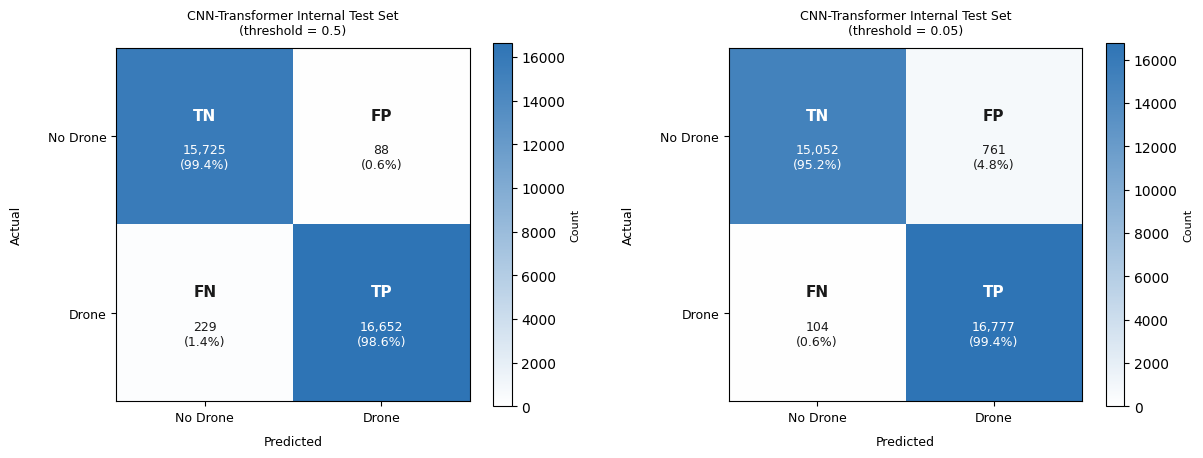

In [16]:
# Internal confusion matrices
fig,axes=plt.subplots(1,2,figsize=(13,5));fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(y_true_eval,(y_prob>=0.5).astype(int)),
        'CNN-Transformer Internal Test Set\n(threshold = 0.5)',axes[0])
plot_cm(confusion_matrix(y_true_eval,(y_prob>=0.05).astype(int)),
        'CNN-Transformer Internal Test Set\n(threshold = 0.05)',axes[1])
save_fig(fig,'cnntf_internal_cm.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_internal_roc.png


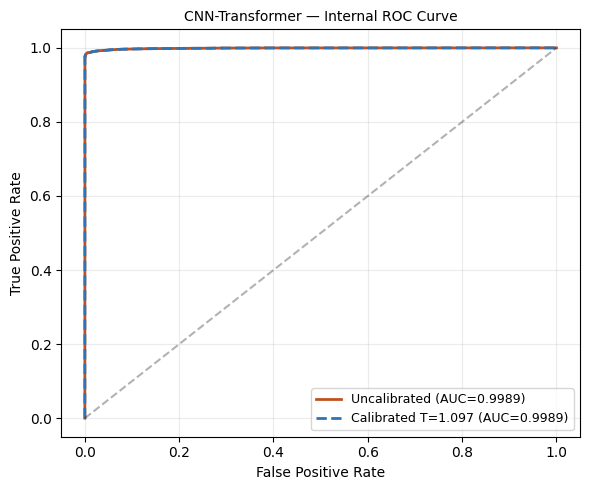

In [17]:
# Internal ROC
fig,ax=plt.subplots(figsize=(6,5))
fpr_u,tpr_u,_=roc_curve(y_true_eval,y_prob)
fpr_c,tpr_c,_=roc_curve(y_true_eval,y_prob_cal)
ax.plot(fpr_u,tpr_u,color='#C05020',lw=2,label=f'Uncalibrated (AUC={int_auc:.4f})')
ax.plot(fpr_c,tpr_c,color='#2E74B5',lw=2,ls='--',label=f'Calibrated T={TEMPERATURE:.3f} (AUC={int_auc_cal:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('False Positive Rate');ax.set_ylabel('True Positive Rate')
ax.set_title('CNN-Transformer — Internal ROC Curve',fontsize=10,fontweight='normal')
ax.legend(fontsize=9);ax.grid(alpha=0.25);plt.tight_layout()
save_fig(fig,'cnntf_internal_roc.png');plt.show()

In [18]:
# External Svanstrom evaluation
EXT_ROOT='/content/external_drone_thesis'
os.makedirs(EXT_ROOT,exist_ok=True)
EXT_ZIP_URL='https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'
EXT_ZIP_PATH=os.path.join(EXT_ROOT,'repo.zip')
EXT_EXTRACT_DIR=os.path.join(EXT_ROOT,'repo')
if not os.path.exists(EXT_ZIP_PATH):
    print('Downloading Svanström...')
    r=requests.get(EXT_ZIP_URL,stream=True);r.raise_for_status()
    with open(EXT_ZIP_PATH,'wb') as f:
        for chunk in r.iter_content(1024*1024): f.write(chunk)
    with zipfile.ZipFile(EXT_ZIP_PATH) as z: z.extractall(EXT_EXTRACT_DIR)

subdirs=[p for p in glob.glob(os.path.join(EXT_EXTRACT_DIR,'*')) if os.path.isdir(p)]
ext_wavs=sorted(glob.glob(os.path.join(subdirs[0],'**','*.wav'),recursive=True))
ext_labels=np.array([1 if 'drone' in os.path.basename(p).lower() else 0 for p in ext_wavs])
print(f'External: {len(ext_wavs)} clips — drone:{ext_labels.sum()}, no-drone:{(ext_labels==0).sum()}')

local_rng=np.random.default_rng(SEED)
ext_clip_probs_uncal=[]
for p in ext_wavs:
    y,sr=librosa.load(p,sr=None,mono=True)
    if sr!=sr_used: y=librosa.resample(y,orig_sr=sr,target_sr=sr_used)
    wins=windows_all(y,sr_used,WIN_S,HOP_S,local_rng);X=[]
    for w in wins:
        if local_rng.random()<AUG_PROB:
            w=add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng)
        X.append(mel_to_model_array(log_mel_db(w,sr_used)))
    if not X: ext_clip_probs_uncal.append(0.0);continue
    logits=model.predict(np.stack(X),batch_size=BATCH,verbose=0).ravel()
    ext_clip_probs_uncal.append(float(np.max(tf.sigmoid(logits).numpy())))

ext_clip_probs_uncal=np.array(ext_clip_probs_uncal)
ext_clip_logits=np.log(ext_clip_probs_uncal/(1-ext_clip_probs_uncal+1e-9)+1e-9)
ext_clip_probs_cal=tf.sigmoid(ext_clip_logits/TEMPERATURE).numpy()

ext_auc_uncal=roc_auc_score(ext_labels,ext_clip_probs_uncal)
ext_auc_cal=roc_auc_score(ext_labels,ext_clip_probs_cal)
print(f'External clip AUC (uncal): {ext_auc_uncal:.4f}')
print(f'External clip AUC (cal):   {ext_auc_cal:.4f}')

for t_thresh,probs,label in [
    (0.5,ext_clip_probs_uncal,'UNCAL t=0.5'),(0.05,ext_clip_probs_uncal,'UNCAL t=0.05'),
    (0.5,ext_clip_probs_cal,'CAL t=0.5'),(0.05,ext_clip_probs_cal,'CAL t=0.05')]:
    pred=(probs>=t_thresh).astype(int)
    print(f'\n=== EXTERNAL ({label}) ===')
    print(confusion_matrix(ext_labels,pred))
    print(classification_report(ext_labels,pred,digits=4))

External: 90 clips — drone:30, no-drone:60
External clip AUC (uncal): 0.5275
External clip AUC (cal):   0.5275

=== EXTERNAL (UNCAL t=0.5) ===
[[11 49]
 [ 3 27]]
              precision    recall  f1-score   support

           0     0.7857    0.1833    0.2973        60
           1     0.3553    0.9000    0.5094        30

    accuracy                         0.4222        90
   macro avg     0.5705    0.5417    0.4034        90
weighted avg     0.6422    0.4222    0.3680        90


=== EXTERNAL (UNCAL t=0.05) ===
[[ 1 59]
 [ 0 30]]
              precision    recall  f1-score   support

           0     1.0000    0.0167    0.0328        60
           1     0.3371    1.0000    0.5042        30

    accuracy                         0.3444        90
   macro avg     0.6685    0.5083    0.2685        90
weighted avg     0.7790    0.3444    0.1899        90


=== EXTERNAL (CAL t=0.5) ===
[[11 49]
 [ 3 27]]
              precision    recall  f1-score   support

           0     0.7857    0

In [19]:
# Window-level external AUC
local_rng=np.random.default_rng(SEED)
all_wl=[];all_yl=[]
for p,lab in zip(ext_wavs,ext_labels):
    y,sr=librosa.load(p,sr=None,mono=True)
    if sr!=sr_used: y=librosa.resample(y,orig_sr=sr,target_sr=sr_used)
    for w in windows_all(y,sr_used,WIN_S,HOP_S,local_rng):
        if local_rng.random()<AUG_PROB:
            w=add_real_noise_snr(w,noise_bank,local_rng.uniform(SNR_MIN,SNR_MAX),local_rng)
        X=mel_to_model_array(log_mel_db(w,sr_used))[None]
        all_wl.append(float(model.predict(X,verbose=0).ravel()[0]));all_yl.append(lab)
win_probs=tf.sigmoid(np.array(all_wl)).numpy()
print(f'Window-level external AUC: {roc_auc_score(all_yl,win_probs):.4f}  ({len(win_probs)} windows)')

Window-level external AUC: 0.5484  (3510 windows)


In [20]:
# Threshold sweep
def run_sweep(int_probs, ext_probs, label):
    rows=[]
    for t in THRESHOLDS:
        _,_,if1=drone_metrics(y_true_eval,int_probs,t)
        _,er,ef1=drone_metrics(ext_labels,ext_probs,t)
        combined=2*if1*er/(if1+er+1e-9)
        rows.append(dict(threshold=t,int_f1=round(if1,4),ext_recall=round(er,4),
                         ext_f1=round(ef1,4),combined=round(combined,4)))
    df=pd.DataFrame(rows);best=df.loc[df['combined'].idxmax()]
    print(f'\n=== {label} ===');print(df.to_string(index=False))
    print(f'Optimal t={best["threshold"]}  combined={best["combined"]}  int_f1={best["int_f1"]}  ext_recall={best["ext_recall"]}')
    return df,best

df_uncal,best_uncal=run_sweep(y_prob,     ext_clip_probs_uncal,'UNCALIBRATED')
df_cal,  best_cal  =run_sweep(y_prob_cal, ext_clip_probs_cal,  f'CALIBRATED T={TEMPERATURE:.4f}')


=== UNCALIBRATED ===
 threshold  int_f1  ext_recall  ext_f1  combined
      0.05  0.9749      1.0000  0.5042    0.9873
      0.10  0.9833      1.0000  0.5172    0.9916
      0.15  0.9861      0.9667  0.5088    0.9763
      0.20  0.9876      0.9667  0.5179    0.9770
      0.25  0.9881      0.9000  0.4954    0.9420
      0.30  0.9887      0.9000  0.5000    0.9423
      0.35  0.9893      0.9000  0.5000    0.9425
      0.40  0.9897      0.9000  0.5094    0.9427
      0.45  0.9903      0.9000  0.5094    0.9430
      0.50  0.9906      0.9000  0.5094    0.9431
      0.55  0.9908      0.8667  0.4952    0.9246
      0.60  0.9907      0.8667  0.5049    0.9246
      0.65  0.9907      0.8667  0.5098    0.9245
      0.70  0.9908      0.8667  0.5149    0.9246
      0.75  0.9906      0.8667  0.5253    0.9245
      0.80  0.9905      0.8667  0.5417    0.9244
      0.85  0.9904      0.8667  0.5417    0.9244
      0.90  0.9902      0.8000  0.5161    0.8850
      0.95  0.9900      0.7667  0.5169    0.864

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_external_cm.png


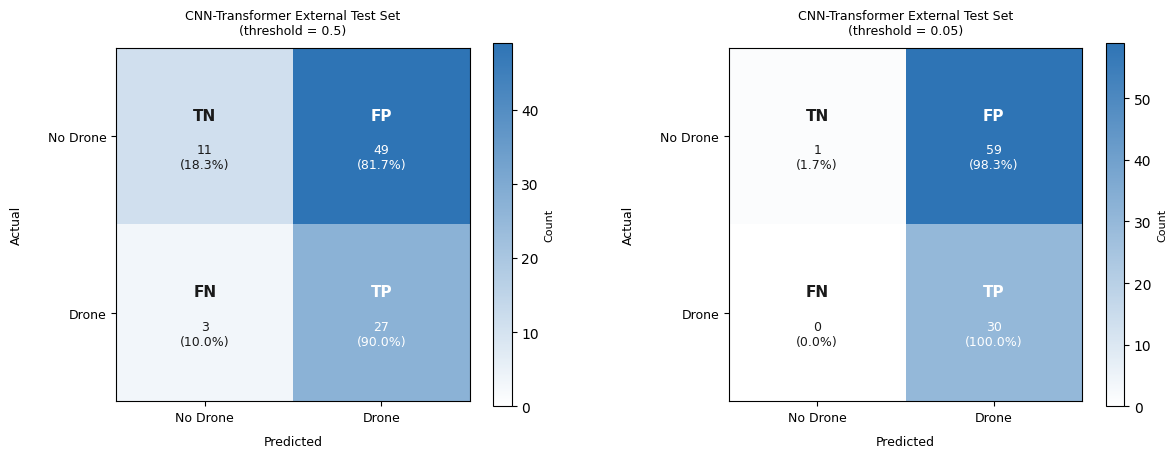

In [21]:
# External confusion matrices
fig,axes=plt.subplots(1,2,figsize=(13,5));fig.subplots_adjust(wspace=0.55)
plot_cm(confusion_matrix(ext_labels,(ext_clip_probs_uncal>=0.5).astype(int)),
        'CNN-Transformer External Test Set\n(threshold = 0.5)',axes[0])
plot_cm(confusion_matrix(ext_labels,(ext_clip_probs_uncal>=0.05).astype(int)),
        'CNN-Transformer External Test Set\n(threshold = 0.05)',axes[1])
save_fig(fig,'cnntf_external_cm.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_threshold_sweep.png


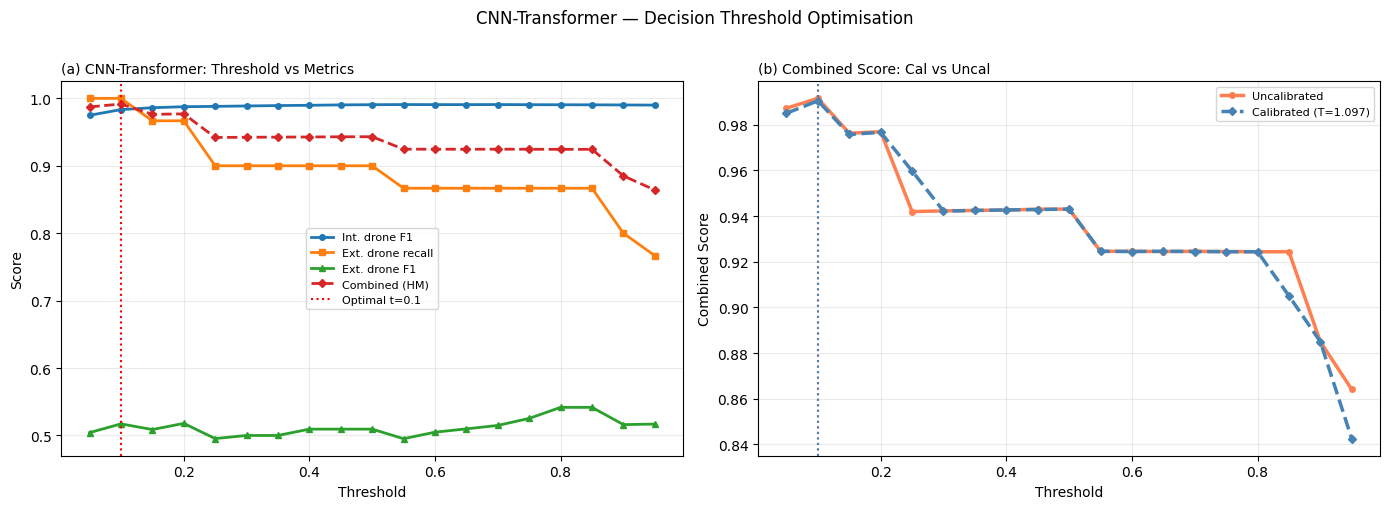

In [22]:
# Threshold sweep plot
fig,axes=plt.subplots(1,2,figsize=(14,5))
ax=axes[0]
ax.plot(df_uncal['threshold'],df_uncal['int_f1'],lw=2,marker='o',ms=4,label='Int. drone F1')
ax.plot(df_uncal['threshold'],df_uncal['ext_recall'],lw=2,marker='s',ms=4,label='Ext. drone recall')
ax.plot(df_uncal['threshold'],df_uncal['ext_f1'],lw=2,marker='^',ms=4,label='Ext. drone F1')
ax.plot(df_uncal['threshold'],df_uncal['combined'],lw=2,ls='--',marker='D',ms=4,label='Combined (HM)')
ax.axvline(float(best_uncal['threshold']),color='red',ls=':',lw=1.5,label=f'Optimal t={best_uncal["threshold"]}')
ax.set_xlabel('Threshold');ax.set_ylabel('Score')
ax.set_title('(a) CNN-Transformer: Threshold vs Metrics',fontsize=10,fontweight='normal',loc='left')
ax.legend(fontsize=8);ax.grid(alpha=0.25)
ax=axes[1]
ax.plot(df_uncal['threshold'],df_uncal['combined'],lw=2.5,color='coral',marker='o',ms=4,label='Uncalibrated')
ax.plot(df_cal['threshold'],df_cal['combined'],lw=2.5,color='steelblue',marker='D',ms=4,ls='--',label=f'Calibrated (T={TEMPERATURE:.3f})')
ax.axvline(float(best_uncal['threshold']),color='coral',ls=':',lw=1.5)
ax.axvline(float(best_cal['threshold']),color='steelblue',ls=':',lw=1.5)
ax.set_xlabel('Threshold');ax.set_ylabel('Combined Score')
ax.set_title('(b) Combined Score: Cal vs Uncal',fontsize=10,fontweight='normal',loc='left')
ax.legend(fontsize=8);ax.grid(alpha=0.25)
fig.suptitle('CNN-Transformer — Decision Threshold Optimisation',fontsize=12,y=1.01);plt.tight_layout()
save_fig(fig,'cnntf_threshold_sweep.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_temperature_scaling.png


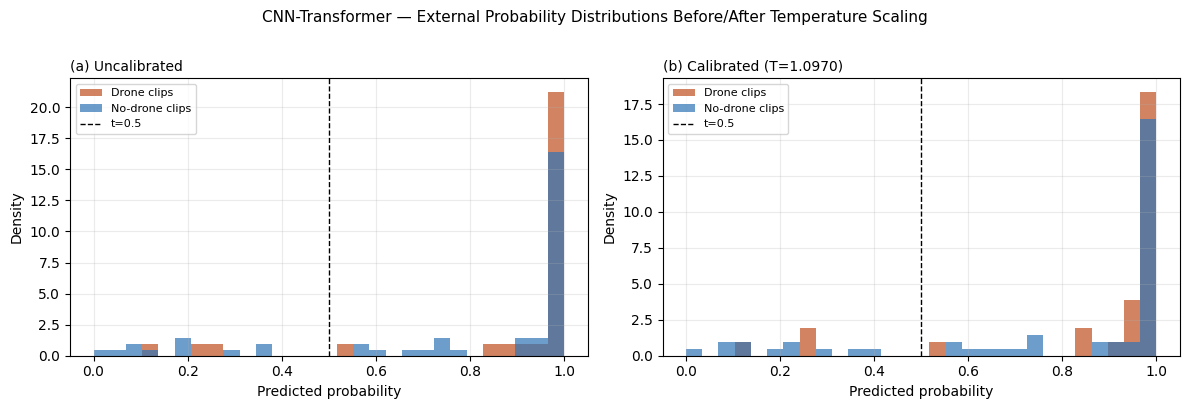

In [23]:
# Temperature scaling distributions
fig,axes=plt.subplots(1,2,figsize=(12,4))
bins=np.linspace(0,1,30);dm=ext_labels==1;ndm=ext_labels==0
for ax,probs,title in [
    (axes[0],ext_clip_probs_uncal,'(a) Uncalibrated'),
    (axes[1],ext_clip_probs_cal,f'(b) Calibrated (T={TEMPERATURE:.4f})')]:
    ax.hist(probs[dm],bins=bins,alpha=0.7,color='#C05020',label='Drone clips',density=True)
    ax.hist(probs[ndm],bins=bins,alpha=0.7,color='#2E74B5',label='No-drone clips',density=True)
    ax.axvline(0.5,color='black',ls='--',lw=1,label='t=0.5')
    ax.set_xlabel('Predicted probability');ax.set_ylabel('Density')
    ax.set_title(title,fontsize=10,fontweight='normal',loc='left')
    ax.legend(fontsize=8);ax.grid(alpha=0.25)
fig.suptitle('CNN-Transformer — External Probability Distributions Before/After Temperature Scaling',
             fontsize=11,y=1.01)
plt.tight_layout();save_fig(fig,'cnntf_temperature_scaling.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/cnntf_external_roc.png


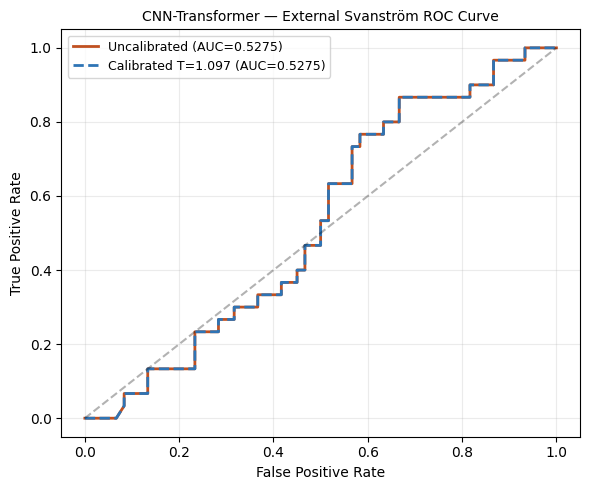

In [24]:
# External ROC
fig,ax=plt.subplots(figsize=(6,5))
fpr_u,tpr_u,_=roc_curve(ext_labels,ext_clip_probs_uncal)
fpr_c,tpr_c,_=roc_curve(ext_labels,ext_clip_probs_cal)
ax.plot(fpr_u,tpr_u,color='#C05020',lw=2,label=f'Uncalibrated (AUC={ext_auc_uncal:.4f})')
ax.plot(fpr_c,tpr_c,color='#2E74B5',lw=2,ls='--',label=f'Calibrated T={TEMPERATURE:.3f} (AUC={ext_auc_cal:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('False Positive Rate');ax.set_ylabel('True Positive Rate')
ax.set_title('CNN-Transformer — External Svanström ROC Curve',fontsize=10,fontweight='normal')
ax.legend(fontsize=9);ax.grid(alpha=0.25);plt.tight_layout()
save_fig(fig,'cnntf_external_roc.png');plt.show()

Saved: /content/drive/MyDrive/drone_audio_processed/figures/comparison_computational_costs.png


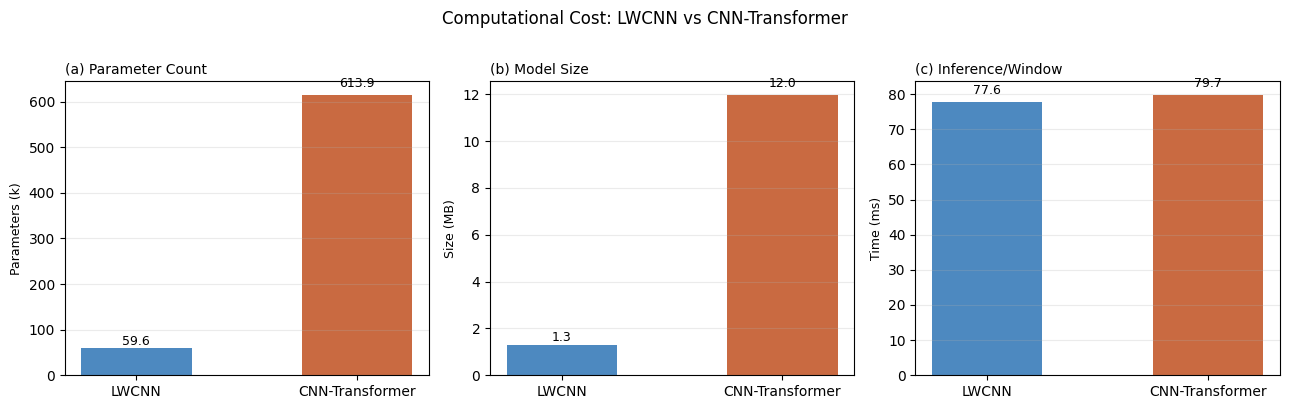

In [25]:
# Computational cost bar chart
if lwcnn_params:
    fig,axes=plt.subplots(1,3,figsize=(13,4))
    models_list=['LWCNN','CNN-Transformer'];colors=['#2E74B5','#C05020']
    for ax,(vals,ylabel,title) in zip(axes,[
        ([lwcnn_params/1e3,n_params/1e3],'Parameters (k)','(a) Parameter Count'),
        ([lwcnn_size,model_size],'Size (MB)','(b) Model Size'),
        ([ms_lwcnn,ms_tf],'Time (ms)','(c) Inference/Window')]):
        bars=ax.bar(models_list,vals,color=colors,width=0.5,alpha=0.85)
        ax.set_ylabel(ylabel,fontsize=9);ax.set_title(title,fontsize=10,fontweight='normal',loc='left')
        ax.grid(axis='y',alpha=0.25)
        for bar,val in zip(bars,vals):
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,f'{val:.1f}',
                    ha='center',va='bottom',fontsize=9)
    fig.suptitle('Computational Cost: LWCNN vs CNN-Transformer',fontsize=12,y=1.01);plt.tight_layout()
    save_fig(fig,'comparison_computational_costs.png');plt.show()

In [26]:
print('\n'+'='*60)
print('CNN-TRANSFORMER — FINAL RESULTS SUMMARY')
print('='*60)
print(f'Parameters         : {n_params:,}')
print(f'Model size         : {model_size:.2f} MB')
print(f'Inference/window   : {ms_tf:.2f} ms')
print(f'Real-time factor   : {ms_tf/500:.5f}x')
print(f'Temperature T      : {TEMPERATURE:.4f}')
print()
print(f'Internal AUC (uncal) : {int_auc:.4f}')
print(f'Internal AUC (cal)   : {int_auc_cal:.4f}')
print(f'External AUC (uncal) : {ext_auc_uncal:.4f}')
print(f'External AUC (cal)   : {ext_auc_cal:.4f}')
print()
print(f'Optimal t (uncal)    : {best_uncal["threshold"]}  combined: {best_uncal["combined"]}')
print(f'Optimal t (cal)      : {best_cal["threshold"]}  combined: {best_cal["combined"]}')
print(f'\nAll figures saved to: {FIG_DIR}')


CNN-TRANSFORMER — FINAL RESULTS SUMMARY
Parameters         : 613,889
Model size         : 11.95 MB
Inference/window   : 79.66 ms
Real-time factor   : 0.15932x
Temperature T      : 1.0970

Internal AUC (uncal) : 0.9989
Internal AUC (cal)   : 0.9989
External AUC (uncal) : 0.5275
External AUC (cal)   : 0.5275

Optimal t (uncal)    : 0.1  combined: 0.9916
Optimal t (cal)      : 0.1  combined: 0.9905

All figures saved to: /content/drive/MyDrive/drone_audio_processed/figures
